In [11]:
import torch

# Setup Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == 'cuda':
    print(torch.cuda.get_device_name(0))

Using device: cuda
NVIDIA GeForce RTX 3050 Laptop GPU


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import numpy as np
import copy

# --- Configuration ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 64
EPOCHS_PER_TASK = 5  
LR = 0.01
HIDDEN_UNITS = 256
SEED = 42

def set_seed(seed=SEED):
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)

In [ ]:
# 1. The Backbone Model
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28 * 28, HIDDEN_UNITS)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(HIDDEN_UNITS, HIDDEN_UNITS)
        self.fc3 = nn.Linear(HIDDEN_UNITS, 10) 

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        return self.fc3(x)

In [ ]:
# 2. Data Manager (Supports Extensions) 
def get_benchmark(dataset_name="MNIST", shuffle_order=False):
    """
    Returns a list of 5 tasks. Each task is a tuple (train_loader, test_loader).
    Supports MNIST (default) and FashionMNIST (extension).
    Supports shuffling task order (extension).
    """
    transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
    
    if dataset_name == "FashionMNIST":
        train_d = datasets.FashionMNIST('./data', train=True, download=True, transform=transform)
        test_d = datasets.FashionMNIST('./data', train=False, download=True, transform=transform)
    else: # Default MNIST
        train_d = datasets.MNIST('./data', train=True, download=True, transform=transform)
        test_d = datasets.MNIST('./data', train=False, download=True, transform=transform)

    # Define tasks: pairs of digits
    task_classes_list = [[0, 1], [2, 3], [4, 5], [6, 7], [8, 9]]
    
    # Extension: Sensitivity to Task Order 
    if shuffle_order:
        np.random.shuffle(task_classes_list)
        print(f"Task Order Shuffled: {task_classes_list}")
    else:
        print(f"Standard Task Order: {task_classes_list}")

    tasks = []
    for task_classes in task_classes_list:
        train_idx = [i for i, label in enumerate(train_d.targets) if label in task_classes]
        test_idx = [i for i, label in enumerate(test_d.targets) if label in task_classes]
        
        train_loader = DataLoader(Subset(train_d, train_idx), batch_size=BATCH_SIZE, shuffle=True)
        test_loader = DataLoader(Subset(test_d, test_idx), batch_size=BATCH_SIZE, shuffle=False)
        tasks.append((train_loader, test_loader))
        
    return tasks

In [ ]:
# 3. The Agent Framework
class NaiveAgent:
    """
    Baseline 1: Sequential Fine-Tuning.
    Just trains on the new data, forgetting the old.
    """
    def __init__(self, device):
        self.model = MLP().to(device)
        self.optimizer = optim.SGD(self.model.parameters(), lr=LR)
        self.criterion = nn.CrossEntropyLoss()
        self.device = device
    
    def train_task(self, train_loader):
        self.model.train()
        for epoch in range(EPOCHS_PER_TASK):
            for data, target in train_loader:
                data, target = data.to(self.device), target.to(self.device)
                self.optimizer.zero_grad()
                output = self.model(data)
                loss = self.criterion(output, target)
                loss.backward()
                self.optimizer.step()
    
    def evaluate(self, loader):
        self.model.eval()
        correct = 0
        with torch.no_grad():
            for data, target in loader:
                data, target = data.to(self.device), target.to(self.device)
                output = self.model(data)
                pred = output.argmax(dim=1, keepdim=True)
                correct += pred.eq(target.view_as(pred)).sum().item()
        return 100. * correct / len(loader.dataset)

In [ ]:
# 4. The Experiment Loop (Evaluation Protocol) 
def run_experiment(agent, tasks):
    num_tasks = len(tasks)
    acc_matrix = np.zeros((num_tasks, num_tasks))
    
    for train_task_id, (train_loader, _) in enumerate(tasks):
        print(f"\nTraining on Task {train_task_id+1}...")
        
        # 1. Train the agent on the current task
        agent.train_task(train_loader)
        
        # 2. Evaluate on ALL tasks seen so far (and future ones for curiosity)
        print(f"Evaluating after Task {train_task_id+1}:")
        for eval_task_id in range(num_tasks):
            _, test_loader = tasks[eval_task_id]
            acc = agent.evaluate(test_loader)
            acc_matrix[train_task_id, eval_task_id] = acc
            if eval_task_id <= train_task_id:
                print(f" -> Task {eval_task_id+1} Accuracy: {acc:.2f}%")
                
    return acc_matrix

In [ ]:
def compute_metrics(acc_matrix):
    # Average Accuracy (last row, all cols) 
    avg_acc = np.mean(acc_matrix[-1, :])
    
    # Average Forgetting [cite: 57]
    # Forgetting_j = max(acc_matrix[:T-1, j]) - acc_matrix[T, j]
    forgetting = []
    num_tasks = acc_matrix.shape[0]
    for j in range(num_tasks - 1): 
        max_acc = np.max(acc_matrix[:-1, j])
        final_acc = acc_matrix[-1, j]
        forgetting.append(max_acc - final_acc)
        
    avg_forget = np.mean(forgetting) if forgetting else 0.0
    return avg_acc, avg_forget

In [ ]:
# 5. Main Execution
if __name__ == "__main__":
    set_seed(42)
    print(f"Using device: {DEVICE}")
    
    # Setup Data
    print("\n--- Loading Benchmark ---")
    tasks = get_benchmark(dataset_name="MNIST") 
    
    # Run Naive Baseline
    print("\n--- Running Naive Baseline ---")
    naive_agent = NaiveAgent(DEVICE)
    naive_acc_matrix = run_experiment(naive_agent, tasks)
    
    # Report
    print("\n--- Naive Baseline Results ---")
    print(naive_acc_matrix)
    avg_acc, avg_forget = compute_metrics(naive_acc_matrix)
    print(f"\nAverage Accuracy: {avg_acc:.2f}%")
    print(f"Average Forgetting: {avg_forget:.2f}%")

Using device: cuda

--- Loading Benchmark ---
Standard Task Order: [[0, 1], [2, 3], [4, 5], [6, 7], [8, 9]]

--- Running Naive Baseline ---

Training on Task 1...
Evaluating after Task 1:
 -> Task 1 Accuracy: 99.91%

Training on Task 2...
Evaluating after Task 2:
 -> Task 1 Accuracy: 0.00%
 -> Task 2 Accuracy: 98.24%

Training on Task 3...
Evaluating after Task 3:
 -> Task 1 Accuracy: 0.00%
 -> Task 2 Accuracy: 0.00%
 -> Task 3 Accuracy: 99.41%

Training on Task 4...
Evaluating after Task 4:
 -> Task 1 Accuracy: 0.00%
 -> Task 2 Accuracy: 0.00%
 -> Task 3 Accuracy: 0.00%
 -> Task 4 Accuracy: 99.55%

Training on Task 5...
Evaluating after Task 5:
 -> Task 1 Accuracy: 0.00%
 -> Task 2 Accuracy: 0.00%
 -> Task 3 Accuracy: 0.00%
 -> Task 4 Accuracy: 0.00%
 -> Task 5 Accuracy: 98.08%

--- Naive Baseline Results ---
[[99.90543735  0.          0.          0.          0.        ]
 [ 0.         98.23702253  0.          0.          0.        ]
 [ 0.          0.         99.41302028  0.          0

In [ ]:
from torch.utils.data import TensorDataset

# Baseline 2: Joint Training Agent (Upper Bound)
class JointAgent:
    """
    Trains on ALL data available up to the current task.
    Used for comparison only to see the 'Upper Bound' of performance.
    """
    def __init__(self, device):
        self.model = MLP().to(device)
        self.optimizer = optim.SGD(self.model.parameters(), lr=LR)
        self.criterion = nn.CrossEntropyLoss()
        self.device = device
        # Memory to store all raw data seen so far
        self.memory_x = []
        self.memory_y = []

    def train_task(self, train_loader):
        # 1. Accumulate new data from the current task into memory
        for data, target in train_loader:
            self.memory_x.append(data)
            self.memory_y.append(target)
        
        # 2. Create a giant dataset of everything seen so far
        all_x = torch.cat(self.memory_x)
        all_y = torch.cat(self.memory_y)
        
        # 3. Create a loader for the accumulated data
        # We train on the combined dataset, essentially restarting training on everything
        dataset = TensorDataset(all_x, all_y)
        loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)
        
        self.model.train()
        for epoch in range(EPOCHS_PER_TASK):
            for data, target in loader:
                data, target = data.to(self.device), target.to(self.device)
                self.optimizer.zero_grad()
                output = self.model(data)
                loss = self.criterion(output, target)
                loss.backward()
                self.optimizer.step()

    def evaluate(self, loader):
        # Re-use the simple evaluation logic
        self.model.eval()
        correct = 0
        with torch.no_grad():
            for data, target in loader:
                data, target = data.to(self.device), target.to(self.device)
                output = self.model(data)
                pred = output.argmax(dim=1, keepdim=True)
                correct += pred.eq(target.view_as(pred)).sum().item()
        return 100. * correct / len(loader.dataset)

# --- Execution ---
print("\n--- Running Joint Training (Upper Bound) ---")
# re-initialize the agent
joint_agent = JointAgent(DEVICE)

# re-use the tasks variable from the previous cell
joint_acc_matrix = run_experiment(joint_agent, tasks)

# Report
print("\n--- Joint Training Results ---")
print(joint_acc_matrix)
j_avg_acc, _ = compute_metrics(joint_acc_matrix)
print(f"\nAverage Accuracy: {j_avg_acc:.2f}% (Target Upper Bound)")


--- Running Joint Training (Upper Bound) ---

Training on Task 1...
Evaluating after Task 1:
 -> Task 1 Accuracy: 99.91%

Training on Task 2...
Evaluating after Task 2:
 -> Task 1 Accuracy: 99.29%
 -> Task 2 Accuracy: 97.36%

Training on Task 3...
Evaluating after Task 3:
 -> Task 1 Accuracy: 99.15%
 -> Task 2 Accuracy: 97.36%
 -> Task 3 Accuracy: 96.32%

Training on Task 4...
Evaluating after Task 4:
 -> Task 1 Accuracy: 98.96%
 -> Task 2 Accuracy: 97.45%
 -> Task 3 Accuracy: 97.01%
 -> Task 4 Accuracy: 96.32%

Training on Task 5...
Evaluating after Task 5:
 -> Task 1 Accuracy: 98.49%
 -> Task 2 Accuracy: 97.89%
 -> Task 3 Accuracy: 96.85%
 -> Task 4 Accuracy: 96.83%
 -> Task 5 Accuracy: 94.81%

--- Joint Training Results ---
[[99.90543735  0.          0.          0.          0.        ]
 [99.29078014 97.35553379  0.          0.          0.        ]
 [99.14893617 97.35553379 96.31803629  0.          0.        ]
 [98.95981087 97.45347698 97.01173959 96.32426989  0.        ]
 [98.48699

In [ ]:
# Baseline 2: "Traditional" Joint Training (Upper Bound)
# This trains on ALL 60,000 images at once, ignoring task boundaries completely.

def get_all_mnist_loaders(batch_size=64):
    """Downloads and returns loaders for the entire MNIST dataset at once."""
    transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
    
    # Load ALL data (digits 0-9 together)
    train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
    test_dataset = datasets.MNIST('./data', train=False, download=True, transform=transform)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    return train_loader, test_loader

def train_traditional_ml(device):
    print("\n=== Running Traditional Joint Training (Upper Bound) ===")
    
    # 1. Setup Model and Data
    model = MLP().to(device)
    optimizer = optim.SGD(model.parameters(), lr=LR)
    criterion = nn.CrossEntropyLoss()
    
    train_loader, test_loader = get_all_mnist_loaders(BATCH_SIZE)
    
    # 2. Train (Standard ML Loop)
    # We train for more epochs because the dataset is 5x larger than a single task
    total_epochs = EPOCHS_PER_TASK * 5 
    print(f"Training on all classes (0-9) simultaneously for {total_epochs} epochs...")
    
    model.train()
    for epoch in range(total_epochs):
        for data, target in train_loader:
            data, target = data.to(device), target.to(device)
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
            
    # 3. Final Evaluation
    model.eval()
    correct = 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()
            
    acc = 100. * correct / len(test_loader.dataset)
    print(f"\nFinal Joint Accuracy: {acc:.2f}%")
    return acc

# Execution
if __name__ == "__main__":
    joint_acc = train_traditional_ml(DEVICE)


=== Running Traditional Joint Training (Upper Bound) ===
Training on all classes (0-9) simultaneously for 25 epochs...

Final Joint Accuracy: 97.79%


In [ ]:
# 1. Define the Replay Agent
class ReplayAgent:
    """
    Experience Replay: Keeps a small buffer of samples from past tasks 
    and mixes them with new data during training.
    """
    def __init__(self, device, samples_per_task=200):
        self.model = MLP().to(device)
        self.optimizer = optim.SGD(self.model.parameters(), lr=LR)
        self.criterion = nn.CrossEntropyLoss()
        self.device = device
        
        self.samples_per_task = samples_per_task
        self.buffer_data = [] # List of tuples (image, label)

    def train_task(self, train_loader):
        self.model.train()
        
        # Create a loader for the buffer (if we have data)
        buffer_loader = None
        if len(self.buffer_data) > 0:
            # Unzip buffer into tensors
            bx, by = zip(*self.buffer_data)
            bx = torch.stack(bx)
            by = torch.stack(by)
            buffer_dataset = torch.utils.data.TensorDataset(bx, by)
            # Buffer batch size can be smaller or equal to main batch size
            buffer_loader = DataLoader(buffer_dataset, batch_size=BATCH_SIZE, shuffle=True)
            buffer_iter = iter(buffer_loader)

        for epoch in range(EPOCHS_PER_TASK):
            for data, target in train_loader:
                data, target = data.to(self.device), target.to(self.device)
                
                # Replay Logic 
                if buffer_loader:
                    try:
                        b_data, b_target = next(buffer_iter)
                    except StopIteration:
                        buffer_iter = iter(buffer_loader) # Restart buffer iterator
                        b_data, b_target = next(buffer_iter)
                    
                    b_data, b_target = b_data.to(self.device), b_target.to(self.device)
                    
                    # Mix current data with buffer data
                    data = torch.cat((data, b_data))
                    target = torch.cat((target, b_target))
                
                self.optimizer.zero_grad()
                output = self.model(data)
                loss = self.criterion(output, target)
                loss.backward()
                self.optimizer.step()
        
        # Update Buffer after task
        self._update_buffer(train_loader)

    def _update_buffer(self, train_loader):
        # We collect all data from the current task
        all_data = []
        all_targets = []
        for x, y in train_loader:
            all_data.append(x)
            all_targets.append(y)
        
        all_data = torch.cat(all_data)
        all_targets = torch.cat(all_targets)
        
        # Randomly select 'samples_per_task' to keep
        n_keep = min(len(all_data), self.samples_per_task)
        indices = np.random.choice(len(all_data), size=n_keep, replace=False)
        
        # Add to permanent buffer
        for idx in indices:
            self.buffer_data.append((all_data[idx].cpu(), all_targets[idx].cpu()))

    def evaluate(self, loader):
        self.model.eval()
        correct = 0
        with torch.no_grad():
            for data, target in loader:
                data, target = data.to(self.device), target.to(self.device)
                output = self.model(data)
                pred = output.argmax(dim=1, keepdim=True)
                correct += pred.eq(target.view_as(pred)).sum().item()
        return 100. * correct / len(loader.dataset)

# 2. Extension: Study of Memory Size 
if __name__ == "__main__":
    memory_sizes = [50, 200, 500] # Compare different buffer sizes
    results = {}

    print(f"\n=== Extension: Memory Size Sensitivity Analysis ===")
    
    for mem_size in memory_sizes:
        print(f"\n--- Running Replay with Buffer Size: {mem_size} samples/task ---")
        
        # reset seed for fair comparison
        set_seed(42) 
        
        # Create fresh agent and data
        tasks = get_benchmark(dataset_name="MNIST") 
        agent = ReplayAgent(DEVICE, samples_per_task=mem_size)
        
        # Run experiment
        acc_matrix = run_experiment(agent, tasks)
        avg_acc, avg_forget = compute_metrics(acc_matrix)
        
        results[mem_size] = (avg_acc, avg_forget)
        print(f"Result for Memory {mem_size} -> Avg Acc: {avg_acc:.2f}%, Forgetting: {avg_forget:.2f}%")

    # Final Summary Table
    print("\n\n=== Final Summary: Memory Size vs Performance ===")
    print(f"{'Buffer Size':<15} | {'Avg Accuracy':<15} | {'Forgetting':<15}")
    print("-" * 50)
    for size, (acc, forget) in results.items():
        print(f"{size:<15} | {acc:.2f}%{'':<9} | {forget:.2f}%")


=== Extension: Memory Size Sensitivity Analysis ===

--- Running Replay with Buffer Size: 50 samples/task ---
Standard Task Order: [[0, 1], [2, 3], [4, 5], [6, 7], [8, 9]]

Training on Task 1...
Evaluating after Task 1:
 -> Task 1 Accuracy: 99.91%

Training on Task 2...
Evaluating after Task 2:
 -> Task 1 Accuracy: 96.78%
 -> Task 2 Accuracy: 97.26%

Training on Task 3...
Evaluating after Task 3:
 -> Task 1 Accuracy: 94.56%
 -> Task 2 Accuracy: 76.40%
 -> Task 3 Accuracy: 98.45%

Training on Task 4...
Evaluating after Task 4:
 -> Task 1 Accuracy: 92.53%
 -> Task 2 Accuracy: 76.54%
 -> Task 3 Accuracy: 79.62%
 -> Task 4 Accuracy: 98.44%

Training on Task 5...
Evaluating after Task 5:
 -> Task 1 Accuracy: 88.13%
 -> Task 2 Accuracy: 63.71%
 -> Task 3 Accuracy: 65.05%
 -> Task 4 Accuracy: 81.62%
 -> Task 5 Accuracy: 96.67%
Result for Memory 50 -> Avg Acc: 79.04%, Forgetting: 23.89%

--- Running Replay with Buffer Size: 200 samples/task ---
Standard Task Order: [[0, 1], [2, 3], [4, 5], [6

## EWC Agent

i did try with different values of LAMBDA, first lambda_ewc = 580000, the best value that doesn't break later tasks (4 and 5) (Plasticity), and hign stability but not as high as the previous  Naive Baseline, so best trade off

In [ ]:
class EWCAgent:
    def __init__(self, device, lambda_ewc=5000): #5000 as default starting point for MNIST
        self.model = MLP().to(device)
        self.optimizer = optim.SGD(self.model.parameters(), lr=LR)
        self.criterion = nn.CrossEntropyLoss()
        self.device = device
        self.lambda_ewc = lambda_ewc
        
        # Store constraints: List of (Fisher_Matrix, Optimal_Params)
        self.previous_tasks = [] 

    def train_task(self, train_loader):
        self.model.train()
        
        for epoch in range(EPOCHS_PER_TASK):
            for batch_idx, (data, target) in enumerate(train_loader):
                data, target = data.to(self.device), target.to(self.device)
                self.optimizer.zero_grad()
                output = self.model(data)
                
                # 1. Main Task Loss
                loss = self.criterion(output, target)
                
                # 2. EWC Penalty
                ewc_loss = 0
                if len(self.previous_tasks) > 0:
                    for fisher, opt_params in self.previous_tasks:
                        for name, param in self.model.named_parameters():
                            f = fisher[name]
                            p_star = opt_params[name]
                            ewc_loss += (f * (param - p_star).pow(2)).sum()
                    
                    loss += (self.lambda_ewc / 2) * ewc_loss
                
                loss.backward()
                
                # 3. SAFETY: Clip gradients to prevent explosion (NaNs)
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), 2.0)
                
                self.optimizer.step()
                
                # Debug print (First batch of first epoch only)
                if epoch == 0 and batch_idx == 0 and len(self.previous_tasks) > 0:
                    print(f"DEBUG: Task Loss={loss.item() - (self.lambda_ewc/2)*ewc_loss.item():.4f} | EWC Penalty={((self.lambda_ewc/2)*ewc_loss).item():.4f}")

        # After task: compute Fisher and save current weights
        self._compute_fisher(train_loader)

    def _compute_fisher(self, loader):
        self.model.eval()
        fisher = {}
        opt_params = {}
        
        for name, param in self.model.named_parameters():
            fisher[name] = torch.zeros_like(param)
            opt_params[name] = param.data.clone()
            
        self.model.zero_grad()
        
        # Accumulate Fisher
        for data, target in loader:
            data, target = data.to(self.device), target.to(self.device)
            output = self.model(data)
            loss = self.criterion(output, target)
            loss.backward()
            
            for name, param in self.model.named_parameters():
                if param.grad is not None:
                    # We multiply by BATCH_SIZE because PyTorch gradients are averaged.
                    # Squaring the average underestimates the variance. 
                    # Multiplying by batch_size is a better approximation of sum-of-squares.
                    fisher[name] += (param.grad.data.pow(2) * data.size(0))
            
            self.model.zero_grad()
            
        # [cite_start]Normalize by total dataset size [cite: 78, 79]
        # This keeps Lambda consistent regardless of dataset size
        for name in fisher:
            fisher[name] /= len(loader.dataset)
            
        self.previous_tasks.append((fisher, opt_params))

    def evaluate(self, loader):
        self.model.eval()
        correct = 0
        with torch.no_grad():
            for data, target in loader:
                data, target = data.to(self.device), target.to(self.device)
                output = self.model(data)
                pred = output.argmax(dim=1, keepdim=True)
                correct += pred.eq(target.view_as(pred)).sum().item()
        return 100. * correct / len(loader.dataset)

# --- Run EWC Comparison ---
if __name__ == "__main__":
    print("\n=== Extension: Comparison with EWC Method (Stable) ===")
    set_seed(42)
    
    tasks = get_benchmark(dataset_name="MNIST") 
    
    ewc_agent = EWCAgent(DEVICE, lambda_ewc=580000) 
    
    ewc_matrix = run_experiment(ewc_agent, tasks)
    
    print("\n--- EWC Results ---")
    print(ewc_matrix)
    avg_acc, avg_forget = compute_metrics(ewc_matrix)
    print(f"\nAverage Accuracy: {avg_acc:.2f}%")
    print(f"Average Forgetting: {avg_forget:.2f}%")


=== Extension: Comparison with EWC Method (Stable) ===
Standard Task Order: [[0, 1], [2, 3], [4, 5], [6, 7], [8, 9]]

Training on Task 1...
Evaluating after Task 1:
 -> Task 1 Accuracy: 99.91%

Training on Task 2...
DEBUG: Task Loss=9.2864 | EWC Penalty=0.0000
Evaluating after Task 2:
 -> Task 1 Accuracy: 0.61%
 -> Task 2 Accuracy: 98.19%

Training on Task 3...
DEBUG: Task Loss=11.4989 | EWC Penalty=0.0168
Evaluating after Task 3:
 -> Task 1 Accuracy: 0.00%
 -> Task 2 Accuracy: 13.71%
 -> Task 3 Accuracy: 94.34%

Training on Task 4...
DEBUG: Task Loss=10.6441 | EWC Penalty=0.2419
Evaluating after Task 4:
 -> Task 1 Accuracy: 0.00%
 -> Task 2 Accuracy: 5.39%
 -> Task 3 Accuracy: 9.61%
 -> Task 4 Accuracy: 98.29%

Training on Task 5...
DEBUG: Task Loss=10.0837 | EWC Penalty=0.6668
Evaluating after Task 5:
 -> Task 1 Accuracy: 41.61%
 -> Task 2 Accuracy: 21.89%
 -> Task 3 Accuracy: 24.12%
 -> Task 4 Accuracy: 90.94%
 -> Task 5 Accuracy: 40.14%

--- EWC Results ---
[[99.90543735  0.      

secondly with the second best lambda value that only breaks the 5th task, lambda = 840000, (High Stability, Broken Plasticity on Task 5)

In [36]:
class EWCAgent:
    def __init__(self, device, lambda_ewc=5000): 
        self.model = MLP().to(device)
        self.optimizer = optim.SGD(self.model.parameters(), lr=LR)
        self.criterion = nn.CrossEntropyLoss()
        self.device = device
        self.lambda_ewc = lambda_ewc
        
        # Store constraints: List of (Fisher_Matrix, Optimal_Params)
        self.previous_tasks = [] 

    def train_task(self, train_loader):
        self.model.train()
        
        for epoch in range(EPOCHS_PER_TASK):
            for batch_idx, (data, target) in enumerate(train_loader):
                data, target = data.to(self.device), target.to(self.device)
                self.optimizer.zero_grad()
                output = self.model(data)
                
                # 1. Main Task Loss
                loss = self.criterion(output, target)
                
                # 2. EWC Penalty
                ewc_loss = 0
                if len(self.previous_tasks) > 0:
                    for fisher, opt_params in self.previous_tasks:
                        for name, param in self.model.named_parameters():
                            f = fisher[name]
                            p_star = opt_params[name]
                            ewc_loss += (f * (param - p_star).pow(2)).sum()
                    
                    loss += (self.lambda_ewc / 2) * ewc_loss
                
                loss.backward()
                
                # 3. SAFETY: Clip gradients to prevent explosion (NaNs)
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), 2.0)
                
                self.optimizer.step()
                
                # Debug print (First batch of first epoch only)
                if epoch == 0 and batch_idx == 0 and len(self.previous_tasks) > 0:
                    print(f"DEBUG: Task Loss={loss.item() - (self.lambda_ewc/2)*ewc_loss.item():.4f} | EWC Penalty={((self.lambda_ewc/2)*ewc_loss).item():.4f}")

        # After task: compute Fisher and save current weights
        self._compute_fisher(train_loader)

    def _compute_fisher(self, loader):
        self.model.eval()
        fisher = {}
        opt_params = {}
        
        for name, param in self.model.named_parameters():
            fisher[name] = torch.zeros_like(param)
            opt_params[name] = param.data.clone()
            
        self.model.zero_grad()
        
        # Accumulate Fisher
        for data, target in loader:
            data, target = data.to(self.device), target.to(self.device)
            output = self.model(data)
            loss = self.criterion(output, target)
            loss.backward()
            
            for name, param in self.model.named_parameters():
                if param.grad is not None:
                    # We multiply by BATCH_SIZE because PyTorch gradients are averaged.
                    # Squaring the average underestimates the variance. 
                    # Multiplying by batch_size is a better approximation of sum-of-squares.
                    fisher[name] += (param.grad.data.pow(2) * data.size(0))
            
            self.model.zero_grad()
            
        # [cite_start]Normalize by total dataset size [cite: 78, 79]
        # This keeps Lambda consistent regardless of dataset size
        for name in fisher:
            fisher[name] /= len(loader.dataset)
            
        self.previous_tasks.append((fisher, opt_params))

    def evaluate(self, loader):
        self.model.eval()
        correct = 0
        with torch.no_grad():
            for data, target in loader:
                data, target = data.to(self.device), target.to(self.device)
                output = self.model(data)
                pred = output.argmax(dim=1, keepdim=True)
                correct += pred.eq(target.view_as(pred)).sum().item()
        return 100. * correct / len(loader.dataset)

# --- Run EWC Comparison ---
if __name__ == "__main__":
    print("\n=== Extension: Comparison with EWC Method (Stable) ===")
    set_seed(42)
    
    tasks = get_benchmark(dataset_name="MNIST") 
    
    # Lambda=5000 is a standard starting point for MNIST
    ewc_agent = EWCAgent(DEVICE, lambda_ewc=840000) 
    
    ewc_matrix = run_experiment(ewc_agent, tasks)
    
    print("\n--- EWC Results ---")
    print(ewc_matrix)
    avg_acc, avg_forget = compute_metrics(ewc_matrix)
    print(f"\nAverage Accuracy: {avg_acc:.2f}%")
    print(f"Average Forgetting: {avg_forget:.2f}%")


=== Extension: Comparison with EWC Method (Stable) ===
Standard Task Order: [[0, 1], [2, 3], [4, 5], [6, 7], [8, 9]]

Training on Task 1...
Evaluating after Task 1:
 -> Task 1 Accuracy: 99.91%

Training on Task 2...
DEBUG: Task Loss=9.2864 | EWC Penalty=0.0000
Evaluating after Task 2:
 -> Task 1 Accuracy: 1.09%
 -> Task 2 Accuracy: 98.19%

Training on Task 3...
DEBUG: Task Loss=11.5108 | EWC Penalty=0.0180
Evaluating after Task 3:
 -> Task 1 Accuracy: 1.94%
 -> Task 2 Accuracy: 21.35%
 -> Task 3 Accuracy: 91.68%

Training on Task 4...
DEBUG: Task Loss=9.8897 | EWC Penalty=0.3334
Evaluating after Task 4:
 -> Task 1 Accuracy: 45.15%
 -> Task 2 Accuracy: 51.96%
 -> Task 3 Accuracy: 88.69%
 -> Task 4 Accuracy: 55.39%

Training on Task 5...
DEBUG: Task Loss=6.6096 | EWC Penalty=1.5057
Evaluating after Task 5:
 -> Task 1 Accuracy: 48.23%
 -> Task 2 Accuracy: 54.70%
 -> Task 3 Accuracy: 88.10%
 -> Task 4 Accuracy: 54.78%
 -> Task 5 Accuracy: 0.00%

--- EWC Results ---
[[99.90543735  0.      

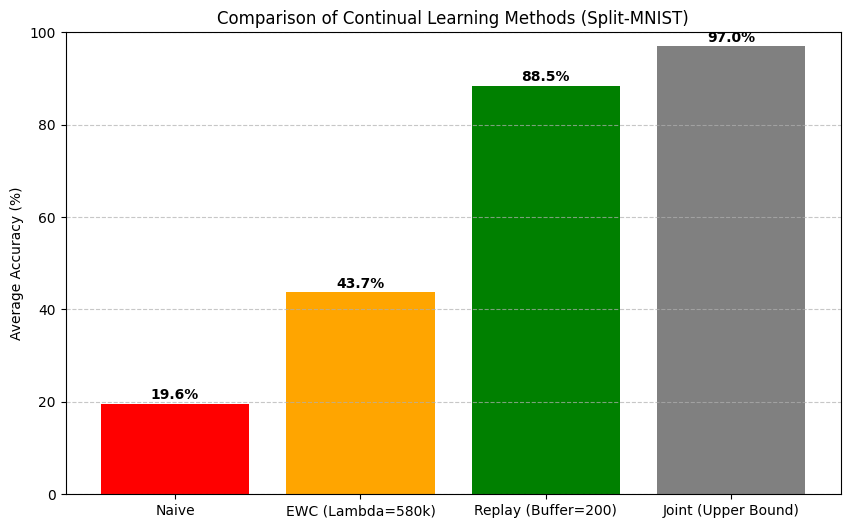

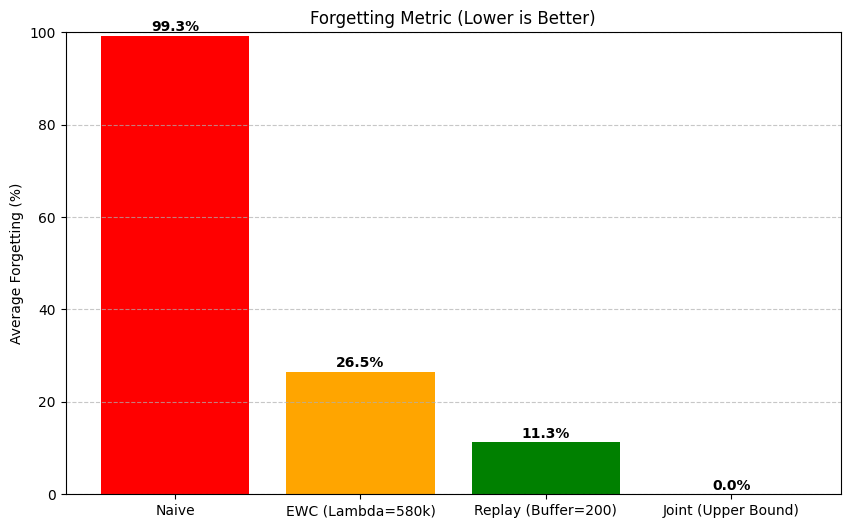

In [ ]:
import matplotlib.pyplot as plt
import numpy as np



# 1. plot the "Average Accuracy" after each task

method_names = ['Naive', 'EWC (Lambda=580k)', 'Replay (Buffer=200)', 'Joint (Upper Bound)']
final_avg_accuracies = [
    19.62,   # Naive result
    43.73,   # EWC result (approx mean of [41.6, 21.9, 24.1, 90.9, 40.1])
    88.45,   # Replay result (Buffer 200)
    96.97    # Joint Training result
]

# 2. Generate Bar Chart
plt.figure(figsize=(10, 6))
bars = plt.bar(method_names, final_avg_accuracies, color=['red', 'orange', 'green', 'grey'])

plt.ylabel('Average Accuracy (%)')
plt.title('Comparison of Continual Learning Methods (Split-MNIST)')
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels on top
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f"{yval:.1f}%", ha='center', fontweight='bold')

plt.show()

# 3. Generate "Forgetting" Comparison
# (Lower is better)
final_forgetting = [
    99.28,  # Naive
    26.50,  # EWC (approx: max - current for first 4 tasks)
    11.29,  # Replay
    0.0     # Joint (Reference)
]

plt.figure(figsize=(10, 6))
bars = plt.bar(method_names, final_forgetting, color=['red', 'orange', 'green', 'grey'])
plt.ylabel('Average Forgetting (%)')
plt.title('Forgetting Metric (Lower is Better)')
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f"{yval:.1f}%", ha='center', fontweight='bold')

plt.show()

In [ ]:
# OPTIONAL EXTENSIONS: Task Order & Fashion-MNIST 

def run_extension_experiment(experiment_name, dataset, shuffle, agent_type="Replay"):
    print(f"\n=== Running Extension: {experiment_name} ===")
    set_seed(42)
    
    # 1. Get Data
    tasks = get_benchmark(dataset_name=dataset, shuffle_order=shuffle)
    
    # 2. Setup Agent (Using Replay as the stable reference)
    # We use a standard buffer size of 200
    if agent_type == "Replay":
        agent = ReplayAgent(DEVICE, samples_per_task=200)
    else:
        agent = NaiveAgent(DEVICE) # Fallback
        
    # 3. Run
    acc_matrix = run_experiment(agent, tasks)
    avg_acc, avg_forget = compute_metrics(acc_matrix)
    
    print(f"\nResult for {experiment_name} -> Avg Acc: {avg_acc:.2f}%, Forgetting: {avg_forget:.2f}%")
    return avg_acc

if __name__ == "__main__":
    # Experiment A: Sensitivity to Task Order
    # We run with shuffle_order=True to see if a random order changes performance
    acc_shuffled = run_extension_experiment(
        experiment_name="Task Order Sensitivity (Shuffled MNIST)", 
        dataset="MNIST", 
        shuffle=True
    )

    # Experiment B: Generalization to Fashion-MNIST
    # We run on a harder dataset (clothing instead of digits)
    acc_fashion = run_extension_experiment(
        experiment_name="Fashion-MNIST Benchmark", 
        dataset="FashionMNIST", 
        shuffle=False
    )

    print("\n\n=== Final Extensions Summary ===")
    print(f"Standard MNIST (Reference): ~88.45%")
    print(f"Shuffled Order MNIST:       {acc_shuffled:.2f}%")
    print(f"Fashion-MNIST (Harder):     {acc_fashion:.2f}%")


=== Running Extension: Task Order Sensitivity (Shuffled MNIST) ===
Task Order Shuffled: [[2, 3], [8, 9], [4, 5], [0, 1], [6, 7]]

Training on Task 1...
Evaluating after Task 1:
 -> Task 1 Accuracy: 97.99%

Training on Task 2...
Evaluating after Task 2:
 -> Task 1 Accuracy: 87.07%
 -> Task 2 Accuracy: 96.87%

Training on Task 3...
Evaluating after Task 3:
 -> Task 1 Accuracy: 82.86%
 -> Task 2 Accuracy: 85.38%
 -> Task 3 Accuracy: 97.28%

Training on Task 4...
Evaluating after Task 4:
 -> Task 1 Accuracy: 84.04%
 -> Task 2 Accuracy: 86.23%
 -> Task 3 Accuracy: 91.89%
 -> Task 4 Accuracy: 99.29%

Training on Task 5...
Evaluating after Task 5:
 -> Task 1 Accuracy: 82.52%
 -> Task 2 Accuracy: 84.01%
 -> Task 3 Accuracy: 88.79%
 -> Task 4 Accuracy: 96.93%
 -> Task 5 Accuracy: 97.18%

Result for Task Order Sensitivity (Shuffled MNIST) -> Avg Acc: 89.89%, Forgetting: 9.80%

=== Running Extension: Fashion-MNIST Benchmark ===


100%|██████████| 26.4M/26.4M [00:05<00:00, 4.87MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 1.93MB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 4.28MB/s]
100%|██████████| 5.15k/5.15k [00:00<?, ?B/s]


Standard Task Order: [[0, 1], [2, 3], [4, 5], [6, 7], [8, 9]]

Training on Task 1...
Evaluating after Task 1:
 -> Task 1 Accuracy: 98.45%

Training on Task 2...
Evaluating after Task 2:
 -> Task 1 Accuracy: 88.60%
 -> Task 2 Accuracy: 93.60%

Training on Task 3...
Evaluating after Task 3:
 -> Task 1 Accuracy: 89.05%
 -> Task 2 Accuracy: 78.90%
 -> Task 3 Accuracy: 92.70%

Training on Task 4...
Evaluating after Task 4:
 -> Task 1 Accuracy: 64.45%
 -> Task 2 Accuracy: 54.55%
 -> Task 3 Accuracy: 62.70%
 -> Task 4 Accuracy: 95.30%

Training on Task 5...
Evaluating after Task 5:
 -> Task 1 Accuracy: 79.00%
 -> Task 2 Accuracy: 72.30%
 -> Task 3 Accuracy: 74.90%
 -> Task 4 Accuracy: 72.80%
 -> Task 5 Accuracy: 97.30%

Result for Fashion-MNIST Benchmark -> Avg Acc: 79.26%, Forgetting: 20.26%


=== Final Extensions Summary ===
Standard MNIST (Reference): ~88.45%
Shuffled Order MNIST:       89.89%
Fashion-MNIST (Harder):     79.26%
